In [830]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as mp
import seaborn as ss

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [831]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [832]:
df.shape

(7043, 21)

In [833]:
df.drop(columns=['customerID'],inplace=True)

In [834]:
val = np.random.randint(0,200,11)

In [835]:
val

array([195,  41, 171, 103,  50, 150,  63,  45,  60,  89, 194])

In [836]:
val

array([195,  41, 171, 103,  50, 150,  63,  45,  60,  89, 194])

In [837]:
df.loc[df['tenure']==0,'TotalCharges']=val

In [838]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors="coerce")
df["SeniorCitizen"] = df['SeniorCitizen'].astype(object)

In [839]:
x = df.iloc[:,0:19]
y = df.iloc[:,-1]

In [840]:
numerical_col = x.select_dtypes(include="number")
cat_col = x.select_dtypes(include="object")

In [841]:
from sklearn.preprocessing import StandardScaler , LabelEncoder , OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoder = LabelEncoder()
std = StandardScaler()

y = encoder.fit_transform(y)
cat_col_ohe = ohe.fit_transform(cat_col)
col = ohe.get_feature_names_out(cat_col.columns)

In [842]:
cat_col_df = pd.DataFrame(cat_col_ohe,columns=col)

In [843]:
numerical_col_trans=std.fit_transform(numerical_col)
numerical_df = pd.DataFrame(numerical_col_trans,columns=numerical_col.columns)

<Axes: >

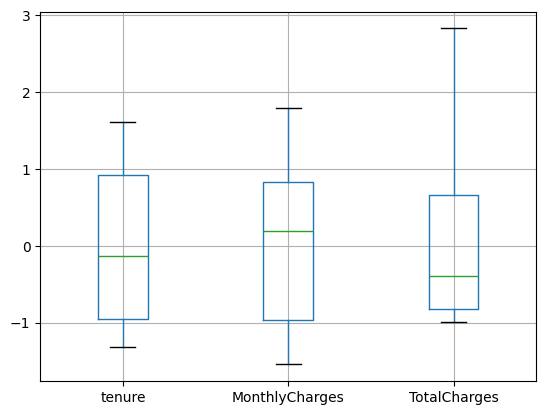

In [844]:
numerical_df.boxplot()

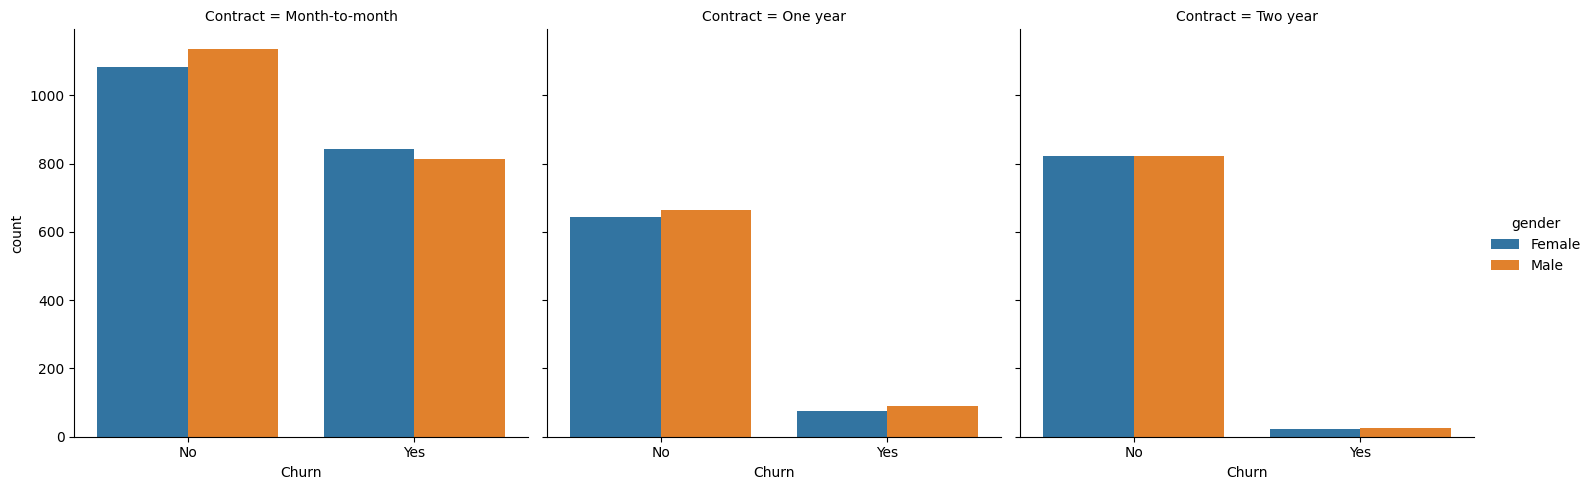

In [845]:
ss.catplot(data=df,x='Churn',hue='gender',col="Contract",kind='count')

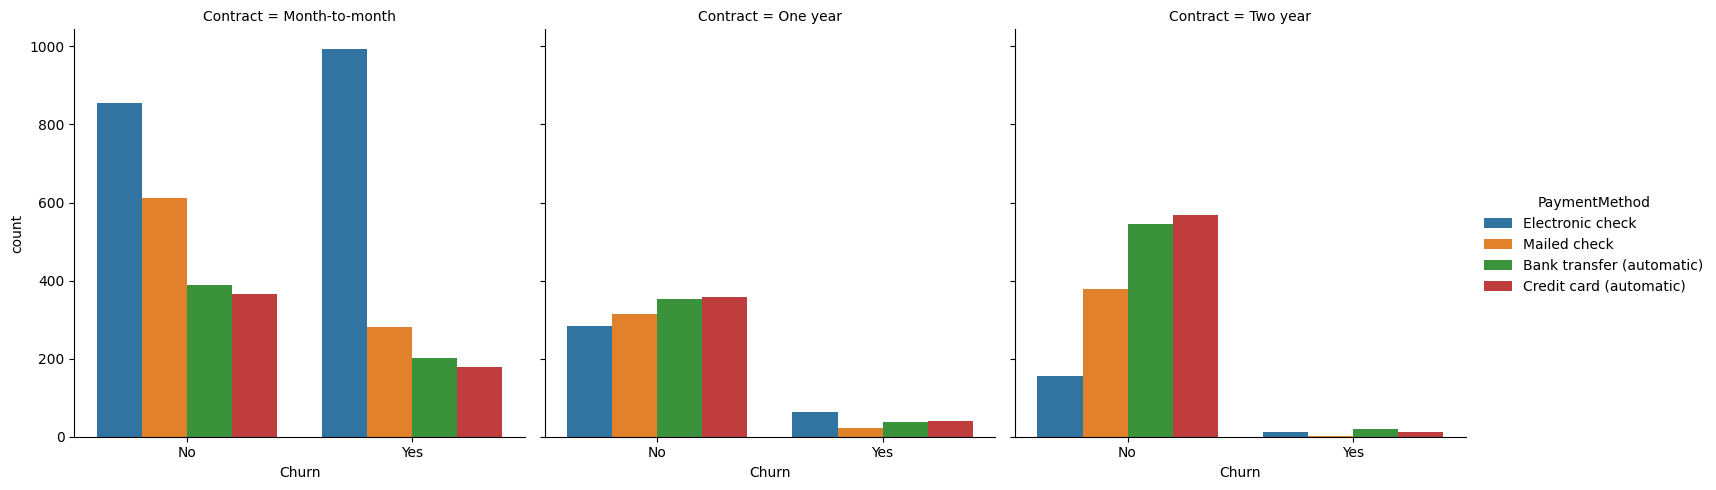

In [846]:
ss.catplot(data=df,x="Churn",hue="PaymentMethod",col="Contract",kind="count")

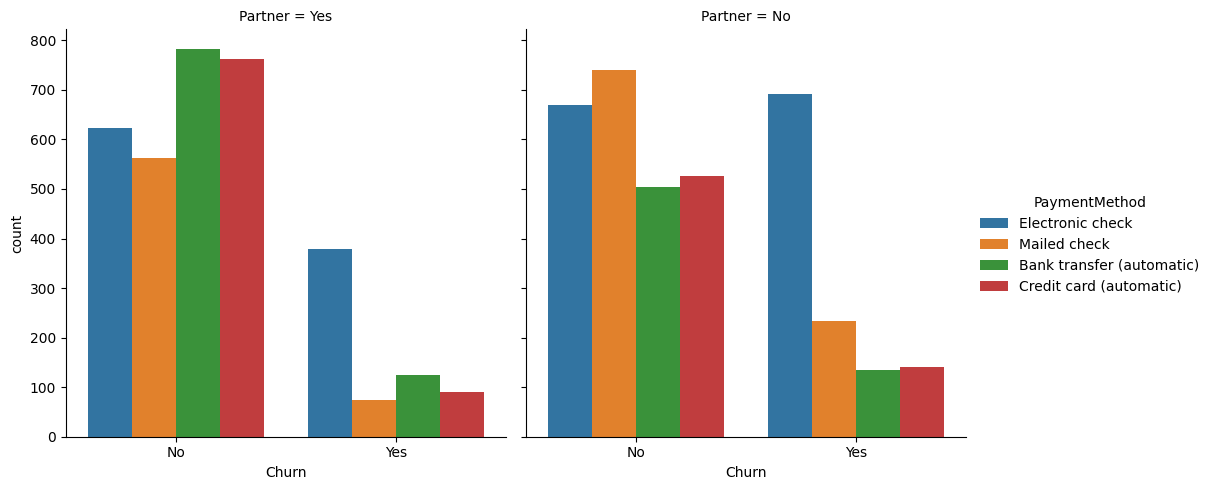

In [847]:
ss.catplot(data=df,x="Churn",hue="PaymentMethod",col="Partner",kind="count")

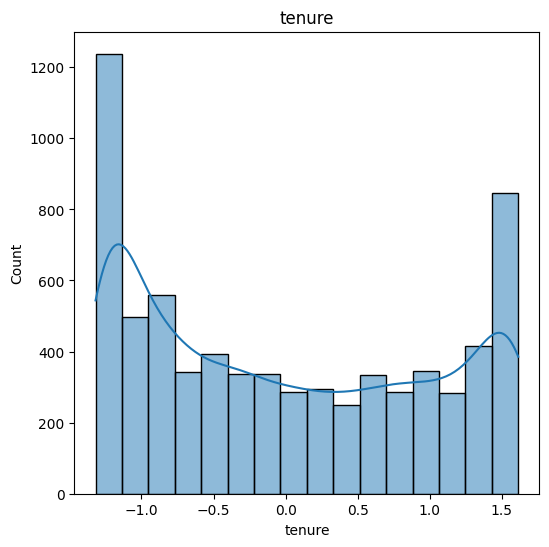

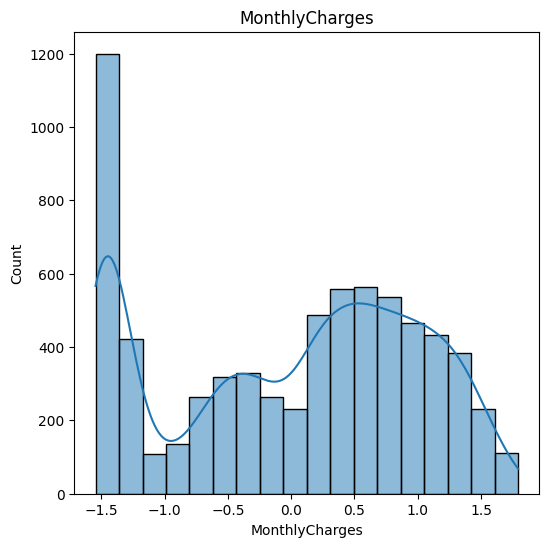

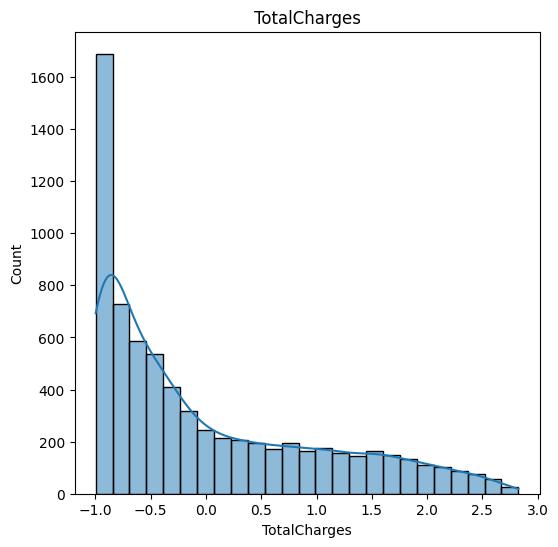

In [848]:
for i in numerical_df.columns: 
    mp.figure(figsize=(6,6))
    ss.histplot(numerical_df[i],kde=True)
    mp.title(i)

In [849]:
from sklearn.model_selection import train_test_split

In [850]:
col = list(numerical_df.columns) + list(cat_col_df.columns)

In [851]:
x = pd.concat((numerical_df,cat_col_df),axis=1)

In [852]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [853]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [854]:
pred = log.predict(x_test)

In [855]:
from sklearn.metrics import accuracy_score , confusion_matrix

In [856]:
accuracy_score(y_test,pred)

0.794180269694819

In [857]:
from sklearn.model_selection import cross_val_score
me = cross_val_score(LogisticRegression(),x,y,cv=10,scoring="accuracy")
np.round(np.mean(me),2)*100

np.float64(80.0)

In [858]:
confusion_matrix(y_test,pred)

array([[914, 118],
       [172, 205]])

In [859]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [860]:
dt = DecisionTreeClassifier(max_depth=7)
svm = SVC(kernel="poly",C=2,gamma=0.2)
knn = KNeighborsClassifier(n_neighbors=5)
log2 = LogisticRegression()

In [861]:
estimator = [('log',log2),('dt',dt),('knn',knn)]

In [862]:
for i in estimator : 
    mean = cross_val_score(i[1], x, y, cv=10, scoring="accuracy")
    print(i[0],np.round(np.mean(mean),2))

log 0.8
dt 0.79
knn 0.77


In [863]:
vot = VotingClassifier(estimators=estimator,voting="soft")
v = cross_val_score(vot,x,y,cv=10,scoring="accuracy")
np.round(np.mean(v),2)*100

np.float64(80.0)